## 0. Librerías

In [4]:
import pandas as pd
import numpy as np
import re
import json
import ast
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR   = Path('datasets/')
OUTPUT_DIR = Path('outputs/')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Librerías OK')

Librerías OK


## 1. Carga de datasets

In [5]:
# --- US Election 2020 (dataset principal) ---
trump_df = pd.read_csv(
    DATA_DIR / 'hashtag_donaldtrump.csv',
    on_bad_lines='skip',
    engine='python'
)
biden_df = pd.read_csv(
    DATA_DIR / 'hashtag_joebiden.csv',
    on_bad_lines='skip',
    engine='python'
)

trump_df['candidate'] = 'trump'
biden_df['candidate'] = 'biden'

election_df = pd.concat([trump_df, biden_df], ignore_index=True)
print(f'US Election 2020 total: {len(election_df):,} tweets')
print('candidate en election_df:', 'candidate' in election_df.columns)

US Election 2020 total: 1,748,160 tweets
candidate en election_df: True


In [6]:
# --- Datasets secundarios (cargados, pendientes de integrar) ---
twitter_df  = pd.read_csv(DATA_DIR / 'twitter_dataset.csv', on_bad_lines='skip', engine='python')
bot_df      = pd.read_csv(DATA_DIR / 'bot_detection_data.csv', on_bad_lines='skip', engine='python')

with open(DATA_DIR / 'cleaned_twitter_elections_data.json', 'r', encoding='utf-8') as f:
    pakistan_raw = json.load(f)
pakistan_df = pd.DataFrame(pakistan_raw) if isinstance(pakistan_raw, list) else pd.json_normalize(pakistan_raw)

print(f'Twitter general:  {len(twitter_df):,} registros')
print(f'Bot detection:    {len(bot_df):,} registros')
print(f'Pakistan 2018:    {len(pakistan_df):,} registros')

Twitter general:  10,000 registros
Bot detection:    50,000 registros
Pakistan 2018:    29,579 registros


## 2. Limpieza de datos
### 2.1 Selección y renombrado de columnas

In [7]:
COLS_ELECTION = {
    'tweet_id':            'tweet_id',
    'tweet':               'text',
    'created_at':          'created_at',
    'user_id':             'user_id',
    'user_screen_name':    'user_screen_name',
    'user_followers_count':'followers_count',
    'user_join_date':      'user_join_date',
    'likes':               'likes',
    'retweet_count':       'retweet_count',
    'source':              'source',
    'user_location':       'user_location',
    'state':               'state',
    'country':             'country',
    'candidate':           'candidate'
}

df = election_df[[c for c in COLS_ELECTION if c in election_df.columns]].rename(columns=COLS_ELECTION)
print(f'Columnas: {df.columns.tolist()}')
print(f'candidate en df: {"candidate" in df.columns}')

Columnas: ['tweet_id', 'text', 'created_at', 'user_id', 'user_screen_name', 'followers_count', 'user_join_date', 'likes', 'retweet_count', 'source', 'user_location', 'state', 'country', 'candidate']
candidate en df: True


### 2.2 Duplicados

In [8]:
n_before = len(df)
df = df.drop_duplicates(subset='tweet_id')
print(f'Duplicados eliminados: {n_before - len(df):,} | Registros restantes: {len(df):,}')

Duplicados eliminados: 225,215 | Registros restantes: 1,522,945


### 2.3 Valores faltantes

In [9]:
# Mostrar nulos antes de limpiar
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')

,missing,pct
tweet_id,1,0.00
text,1,0.00
user_id,38,0.00
user_screen_name,34,0.00
followers_count,250,0.02
user_join_date,280,0.02
likes,20,0.00
retweet_count,34,0.00
source,1009,0.07
user_location,462967,30.40


In [10]:
# Eliminar filas sin texto ni timestamp
df = df.dropna(subset=['text', 'created_at'])

# Forzar tipos numéricos antes de rellenar
df['likes']           = pd.to_numeric(df['likes'],           errors='coerce').fillna(0)
df['retweet_count']   = pd.to_numeric(df['retweet_count'],   errors='coerce').fillna(0)
df['followers_count'] = pd.to_numeric(df['followers_count'], errors='coerce').fillna(0)

# Rellenar opcionales
df['user_location'] = df['user_location'].fillna('unknown')
df['state']         = df['state'].fillna('unknown')
df['country']       = df['country'].fillna('unknown')
df['source']        = df['source'].fillna('unknown')

print(f'Registros finales: {len(df):,}')

Registros finales: 1,522,944


## 3. Normalización temporal

In [11]:
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
df = df.dropna(subset=['created_at'])

df['date']        = df['created_at'].dt.date
df['hour']        = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek
df['week']        = df['created_at'].dt.isocalendar().week.astype(int)
df['hour_window'] = df['created_at'].dt.floor('1h')

print(f'Rango temporal: {df["created_at"].min().date()} → {df["created_at"].max().date()}')

Rango temporal: 2020-10-15 → 2020-11-08


In [12]:
if 'user_join_date' in df.columns:
    df['user_join_date']    = pd.to_datetime(df['user_join_date'], utc=True, errors='coerce')
    df['account_age_days']  = (df['created_at'] - df['user_join_date']).dt.days.clip(lower=0)
else:
    df['account_age_days'] = np.nan

print('account_age_days OK')

account_age_days OK


## 4. Preprocesamiento textual

In [13]:
tokenizer  = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)
lemmatizer = WordNetLemmatizer()
STOP_EN    = set(stopwords.words('english'))

def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text).lower())

def extract_mentions(text):
    return re.findall(r'@(\w+)', str(text).lower())

def is_retweet(text):
    return str(text).strip().startswith('RT @')

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'RT\s@\w+:', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s#]', '', text)
    tokens = tokenizer.tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in STOP_EN and len(t) > 2 and not t.startswith('#')
    ]
    return ' '.join(tokens)

print('Funciones de texto definidas')

Funciones de texto definidas


In [14]:
df['hashtags']  = df['text'].apply(extract_hashtags)
df['mentions']  = df['text'].apply(extract_mentions)
df['is_retweet']= df['text'].apply(is_retweet).astype(int)
df['n_hashtags']= df['hashtags'].apply(len)
df['n_mentions']= df['mentions'].apply(len)

print('Limpiando texto (puede tardar unos minutos)...')
df['text_clean'] = df['text'].apply(clean_text)
print('Texto limpiado')

Limpiando texto (puede tardar unos minutos)...
Texto limpiado


## 5. Feature Engineering
### 5.1 Actividad por cuenta

In [15]:
df['likes']         = pd.to_numeric(df['likes'],         errors='coerce').fillna(0)
df['retweet_count'] = pd.to_numeric(df['retweet_count'], errors='coerce').fillna(0)
df['n_hashtags']    = pd.to_numeric(df['n_hashtags'],    errors='coerce').fillna(0)

user_activity = (
    df.groupby('user_id')
    .agg(
        total_tweets  =('tweet_id',    'count'),
        total_retweets=('is_retweet',  'sum'),
        unique_days   =('date',        'nunique'),
        avg_likes     =('likes',       'mean'),
        avg_rt        =('retweet_count','mean'),
        avg_hashtags  =('n_hashtags',  'mean'),
    )
    .reset_index()
)
user_activity['retweet_ratio'] = (
    user_activity['total_retweets'] / user_activity['total_tweets'].clip(lower=1)
)

df = df.merge(user_activity, on='user_id', how='left')
print(f'Cuentas únicas: {len(user_activity):,}')

Cuentas únicas: 483,189


### 5.2 Densidad temporal por ventana de 1 hora

In [16]:
window_activity = (
    df.groupby('hour_window')
    .agg(
        tweets_in_window      =('tweet_id',   'count'),
        unique_users_in_window=('user_id',    'nunique'),
        rt_in_window          =('is_retweet', 'sum'),
    )
    .reset_index()
)
window_activity['rt_ratio_window'] = (
    window_activity['rt_in_window'] / window_activity['tweets_in_window'].clip(lower=1)
)

df = df.merge(window_activity, on='hour_window', how='left')
print('Features de ventana temporal creadas')

Features de ventana temporal creadas


### 5.3 Muestra estratificada

In [17]:
SAMPLE_N = 200_000

trump_sample = df[df['candidate'] == 'trump'].sample(
    min(len(df[df['candidate'] == 'trump']), SAMPLE_N // 2), random_state=42)
biden_sample = df[df['candidate'] == 'biden'].sample(
    min(len(df[df['candidate'] == 'biden']), SAMPLE_N // 2), random_state=42)

df_sample = pd.concat([trump_sample, biden_sample]).reset_index(drop=True)

print(f'Muestra de trabajo: {len(df_sample):,} tweets')
print(f'candidate en df_sample: {"candidate" in df_sample.columns}')
print(df_sample['candidate'].value_counts())

Muestra de trabajo: 200,000 tweets
candidate en df_sample: True
candidate
trump    100000
biden    100000
Name: count, dtype: int64


### 5.4 Vectorización TF-IDF

In [18]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True
)
tfidf_matrix = tfidf.fit_transform(df_sample['text_clean'])
print(f'Matriz TF-IDF: {tfidf_matrix.shape}')

Matriz TF-IDF: (200000, 5000)


### 5.5 Feature tabular escalada

In [19]:
NUMERIC_FEATURES = [
    'followers_count', 'likes', 'retweet_count',
    'n_hashtags', 'n_mentions', 'is_retweet',
    'hour', 'day_of_week', 'account_age_days',
    'total_tweets', 'retweet_ratio', 'avg_likes',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window',
]

# Usar solo las que existen
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if c in df_sample.columns]
print(f'Features disponibles: {NUMERIC_FEATURES}')

features_df     = df_sample[NUMERIC_FEATURES].fillna(0)
scaler          = MinMaxScaler()
features_scaled = scaler.fit_transform(features_df)
features_scaled_df = pd.DataFrame(features_scaled, columns=NUMERIC_FEATURES)

print(f'Feature matrix: {features_scaled_df.shape}')
features_scaled_df.describe().T[['mean', 'std', 'min', 'max']]

Features disponibles: ['followers_count', 'likes', 'retweet_count', 'n_hashtags', 'n_mentions', 'is_retweet', 'hour', 'day_of_week', 'account_age_days', 'total_tweets', 'retweet_ratio', 'avg_likes', 'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window']
Feature matrix: (200000, 15)


,mean,std,min,max
followers_count,0.000279,0.004656,0.0,1.0
likes,0.000235,0.005073,0.0,1.0
retweet_count,0.000177,0.004543,0.0,1.0
n_hashtags,0.095218,0.087246,0.0,1.0
n_mentions,0.013535,0.035903,0.0,1.0
is_retweet,0.000125,0.011180,0.0,1.0
hour,0.540038,0.311537,0.0,1.0
day_of_week,0.578211,0.307024,0.0,1.0
account_age_days,0.428104,0.289498,0.0,1.0
total_tweets,0.037266,0.096656,0.0,1.0


## 6. Detección preliminar de anomalías

In [20]:
p95 = window_activity['tweets_in_window'].quantile(0.95)
p99 = window_activity['tweets_in_window'].quantile(0.99)
print(f'Tweets por ventana — P95: {p95:.0f} | P99: {p99:.0f}')

burst_windows = window_activity[window_activity['tweets_in_window'] >= p95].copy()
print(f'Ventanas con burst (>= P95): {len(burst_windows):,}')
burst_windows.sort_values('tweets_in_window', ascending=False).head(10)

Tweets por ventana — P95: 7170 | P99: 14661
Ventanas con burst (>= P95): 30


,hour_window,tweets_in_window,unique_users_in_window,rt_in_window,rt_ratio_window
569,2020-11-07 17:00:00+00:00,46416,39072,4,0.000086
568,2020-11-07 16:00:00+00:00,38179,32747,1,0.000026
570,2020-11-07 18:00:00+00:00,28653,24302,7,0.000244
571,2020-11-07 19:00:00+00:00,19022,16157,4,0.000210
194,2020-10-23 02:00:00+00:00,17445,10188,2,0.000115
193,2020-10-23 01:00:00+00:00,16199,8467,0,0.000000
572,2020-11-07 20:00:00+00:00,14645,12184,1,0.000068
573,2020-11-07 21:00:00+00:00,12708,10498,0,0.000000
487,2020-11-04 07:00:00+00:00,12387,9231,0,0.000000
577,2020-11-08 01:00:00+00:00,12343,9458,0,0.000000


## 7. Guardado de artefactos (A3)

In [21]:
df_sample.to_csv(OUTPUT_DIR / 'df_processed_sample.csv', index=False)
features_scaled_df.to_csv(OUTPUT_DIR / 'features_scaled.csv', index=False)
burst_windows.to_csv(OUTPUT_DIR / 'burst_windows.csv', index=False)

import scipy.sparse as sp
sp.save_npz(OUTPUT_DIR / 'tfidf_matrix.npz', tfidf_matrix)

print('Artefactos guardados en outputs/')

Artefactos guardados en outputs/


## 8. Resumen general del dataset

In [22]:
print('=== Resumen general ===')
print(f"Tweets totales:        {len(df_sample):,}")
print(f"Cuentas únicas:        {df_sample['user_id'].nunique():,}")
print(f"Período:               {df_sample['created_at'].min().date()} → {df_sample['created_at'].max().date()}")
print(f"Retweets:              {df_sample['is_retweet'].sum():,} ({df_sample['is_retweet'].mean()*100:.1f}%)")
print(f"Tweets con hashtag:    {(df_sample['n_hashtags'] > 0).sum():,} ({(df_sample['n_hashtags'] > 0).mean()*100:.1f}%)")
print()
print('--- Por candidato ---')
print(df_sample['candidate'].value_counts())

=== Resumen general ===
Tweets totales:        200,000
Cuentas únicas:        116,495
Período:               2020-10-15 → 2020-11-08
Retweets:              25 (0.0%)
Tweets con hashtag:    199,984 (100.0%)

--- Por candidato ---
candidate
trump    100000
biden    100000
Name: count, dtype: int64


In [23]:
cols_desc = ['likes', 'retweet_count', 'followers_count', 'n_hashtags',
             'n_mentions', 'account_age_days', 'total_tweets', 'retweet_ratio']
cols_desc = [c for c in cols_desc if c in df_sample.columns]
df_sample[cols_desc].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
likes,200000.0,9.00,194.03,0.0,0.0,0.0,2.0,38248.0
retweet_count,200000.0,2.02,51.83,0.0,0.0,0.0,0.0,11407.0
followers_count,200000.0,22966.34,383738.79,0.0,74.0,423.0,2009.0,82417099.0
n_hashtags,200000.0,3.81,3.49,0.0,2.0,3.0,5.0,40.0
n_mentions,200000.0,0.68,1.80,0.0,0.0,0.0,1.0,50.0
account_age_days,199969.0,2238.05,1513.07,0.0,676.0,2427.0,3622.0,5227.0
total_tweets,199999.0,50.38,130.68,1.0,2.0,8.0,37.0,1352.0
retweet_ratio,199999.0,0.00,0.01,0.0,0.0,0.0,0.0,1.0


## 9. Distribución temporal
### 9.1 Tweets por día

### 9.2 Tweets por hora del día

### 9.3 Mapa de calor: actividad hora × día de la semana

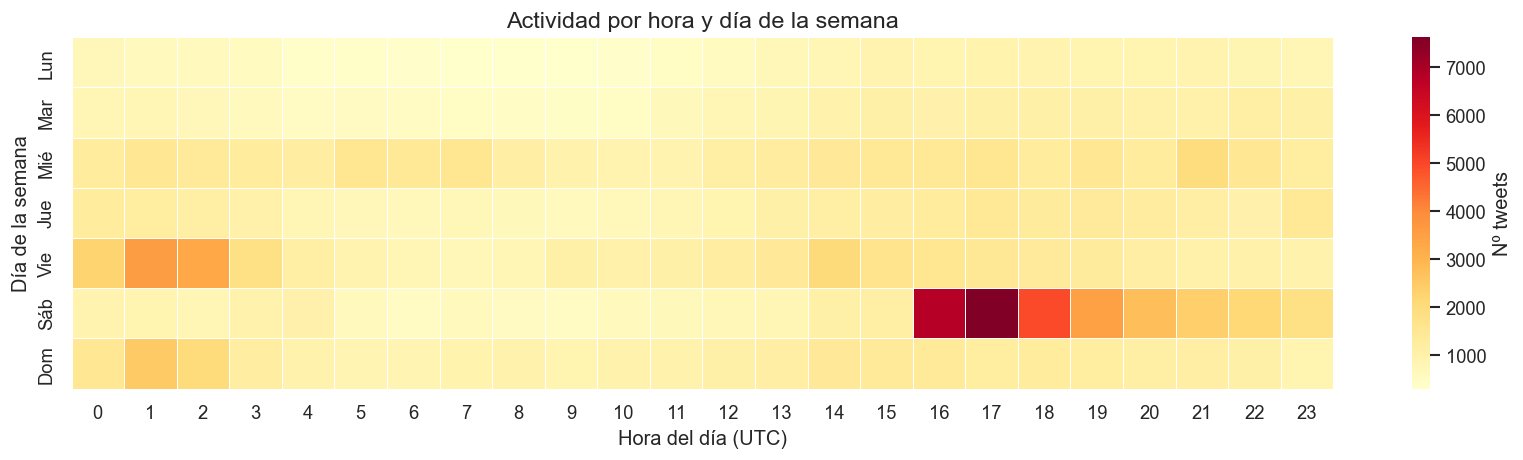

In [24]:
heatmap_data = df_sample.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3, cbar_kws={'label': 'Nº tweets'})
ax.set_title('Actividad por hora y día de la semana', fontsize=14)
ax.set_xlabel('Hora del día (UTC)')
ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_heatmap_hora_dia.png')
plt.show()

### 9.4 Ventanas con burst de actividad (top 20)

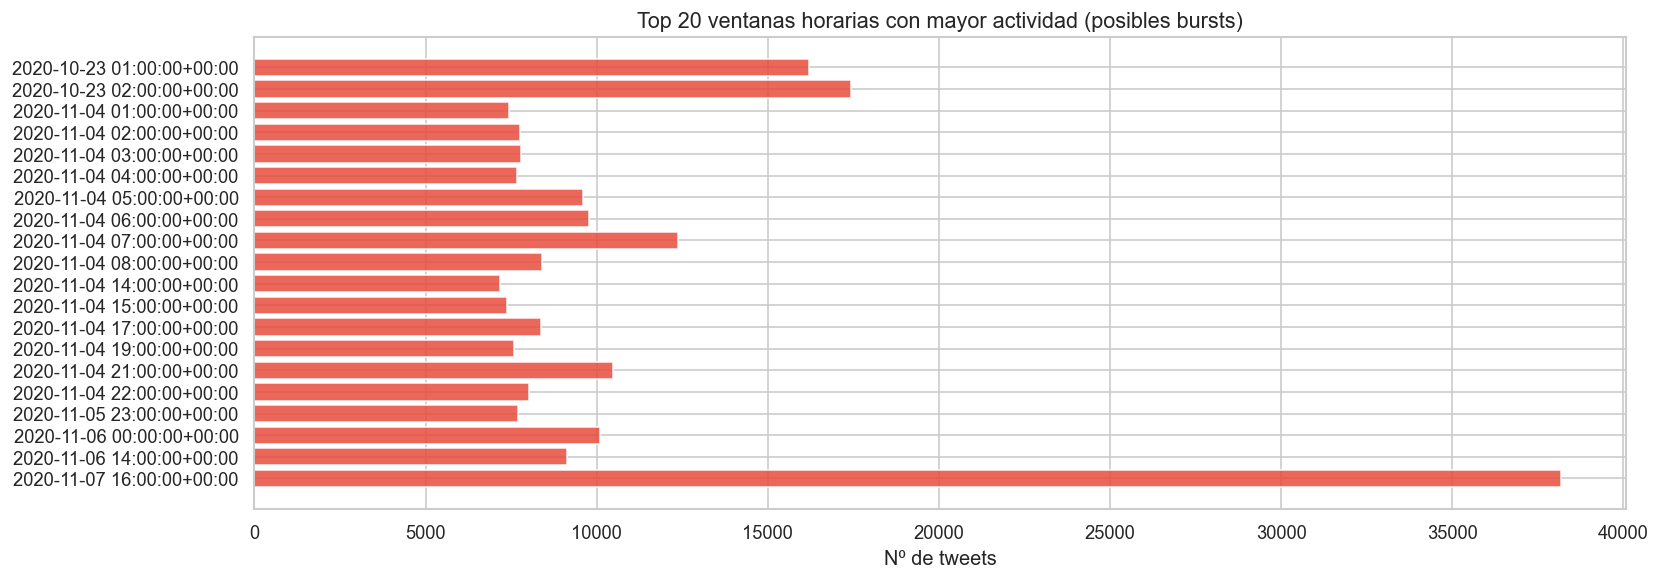

In [25]:
top20 = burst_windows.head(20)
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(top20['hour_window'].astype(str), top20['tweets_in_window'], color='#E74C3C', alpha=0.85)
ax.set_title('Top 20 ventanas horarias con mayor actividad (posibles bursts)', fontsize=13)
ax.set_xlabel('Nº de tweets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_burst_windows.png')
plt.show()

## 10. Análisis de cuentas
### 10.1 Distribución de tweets por cuenta

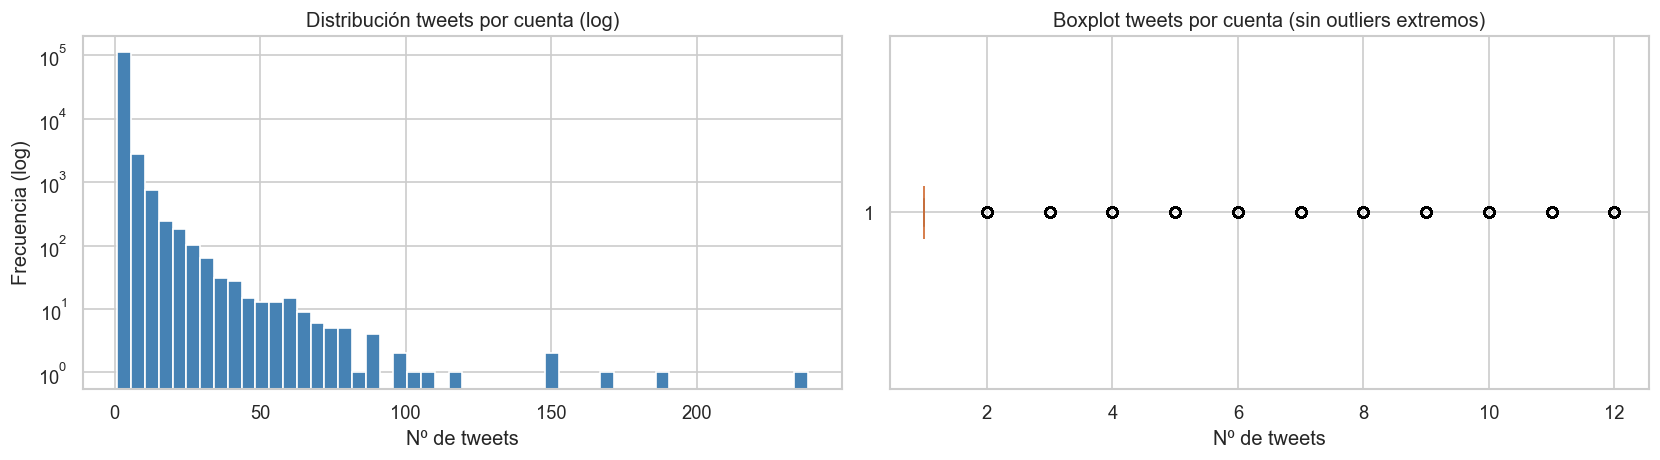

Cuentas con 1 tweet:       90,115
Cuentas con > 50 tweets:   78
Cuentas con > 100 tweets:  8


In [26]:
tweets_per_user = df_sample.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(tweets_per_user, bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Distribución tweets por cuenta (log)', fontsize=12)
axes[0].set_xlabel('Nº de tweets')
axes[0].set_ylabel('Frecuencia (log)')

axes[1].boxplot(tweets_per_user.clip(upper=tweets_per_user.quantile(0.99)),
                vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot tweets por cuenta (sin outliers extremos)', fontsize=12)
axes[1].set_xlabel('Nº de tweets')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tweets_por_cuenta.png')
plt.show()

print(f'Cuentas con 1 tweet:       {(tweets_per_user == 1).sum():,}')
print(f'Cuentas con > 50 tweets:   {(tweets_per_user > 50).sum():,}')
print(f'Cuentas con > 100 tweets:  {(tweets_per_user > 100).sum():,}')

### 10.2 Retweet ratio por cuenta

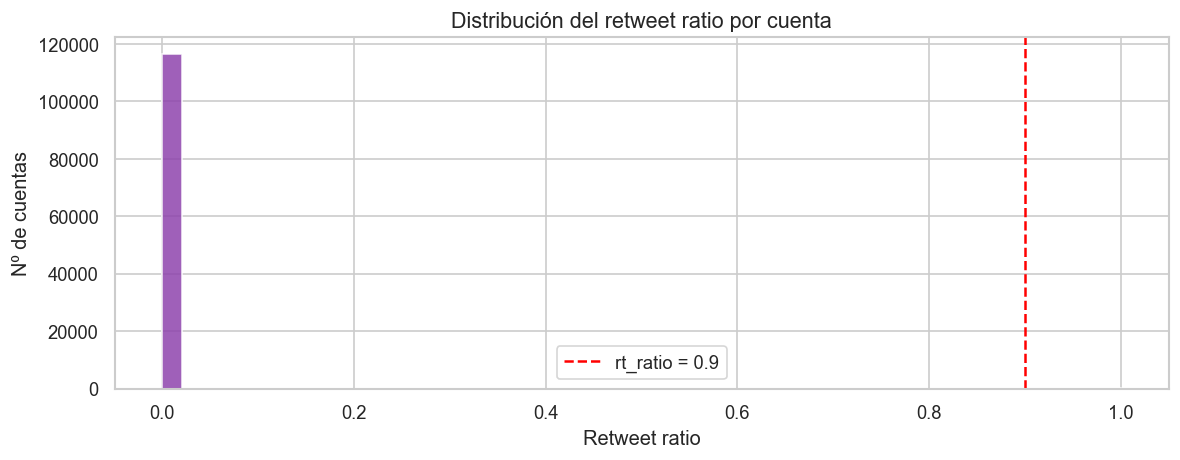

Cuentas con rt_ratio >= 0.9: 14 (0.0%)


In [27]:
user_stats = df_sample.groupby('user_id').agg(
    total=('tweet_id', 'count'),
    rts  =('is_retweet', 'sum')
).reset_index()
user_stats['rt_ratio'] = user_stats['rts'] / user_stats['total'].clip(lower=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(user_stats['rt_ratio'], bins=50, color='#8E44AD', edgecolor='white', alpha=0.85)
ax.axvline(0.9, color='red', linestyle='--', label='rt_ratio = 0.9')
ax.set_title('Distribución del retweet ratio por cuenta', fontsize=13)
ax.set_xlabel('Retweet ratio')
ax.set_ylabel('Nº de cuentas')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_retweet_ratio.png')
plt.show()

high_rt = (user_stats['rt_ratio'] >= 0.9).sum()
print(f'Cuentas con rt_ratio >= 0.9: {high_rt:,} ({high_rt/len(user_stats)*100:.1f}%)')

### 10.3 Antigüedad de cuenta

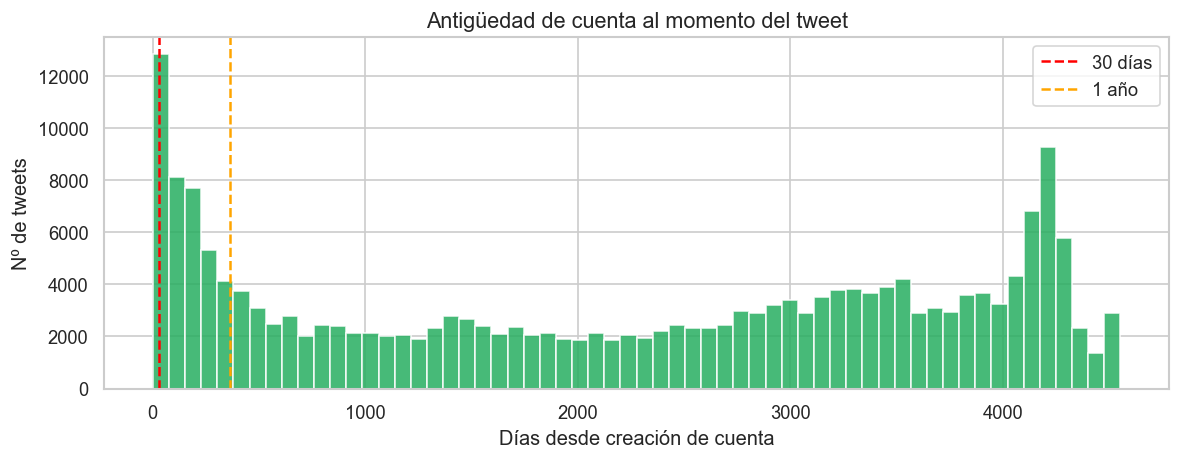

Tweets de cuentas con <= 30 días: 6,824 (3.4%)


In [28]:
if 'account_age_days' in df_sample.columns:
    age = df_sample['account_age_days'].dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(age.clip(upper=age.quantile(0.99)), bins=60, color='#27AE60', edgecolor='white', alpha=0.85)
    ax.axvline(30,  color='red',    linestyle='--', label='30 días')
    ax.axvline(365, color='orange', linestyle='--', label='1 año')
    ax.set_title('Antigüedad de cuenta al momento del tweet', fontsize=13)
    ax.set_xlabel('Días desde creación de cuenta')
    ax.set_ylabel('Nº de tweets')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'eda_antiguedad_cuenta.png')
    plt.show()
    nuevas = (age <= 30).sum()
    print(f'Tweets de cuentas con <= 30 días: {nuevas:,} ({nuevas/len(age)*100:.1f}%)')

## 11. Análisis de contenido
### 11.1 Hashtags más frecuentes

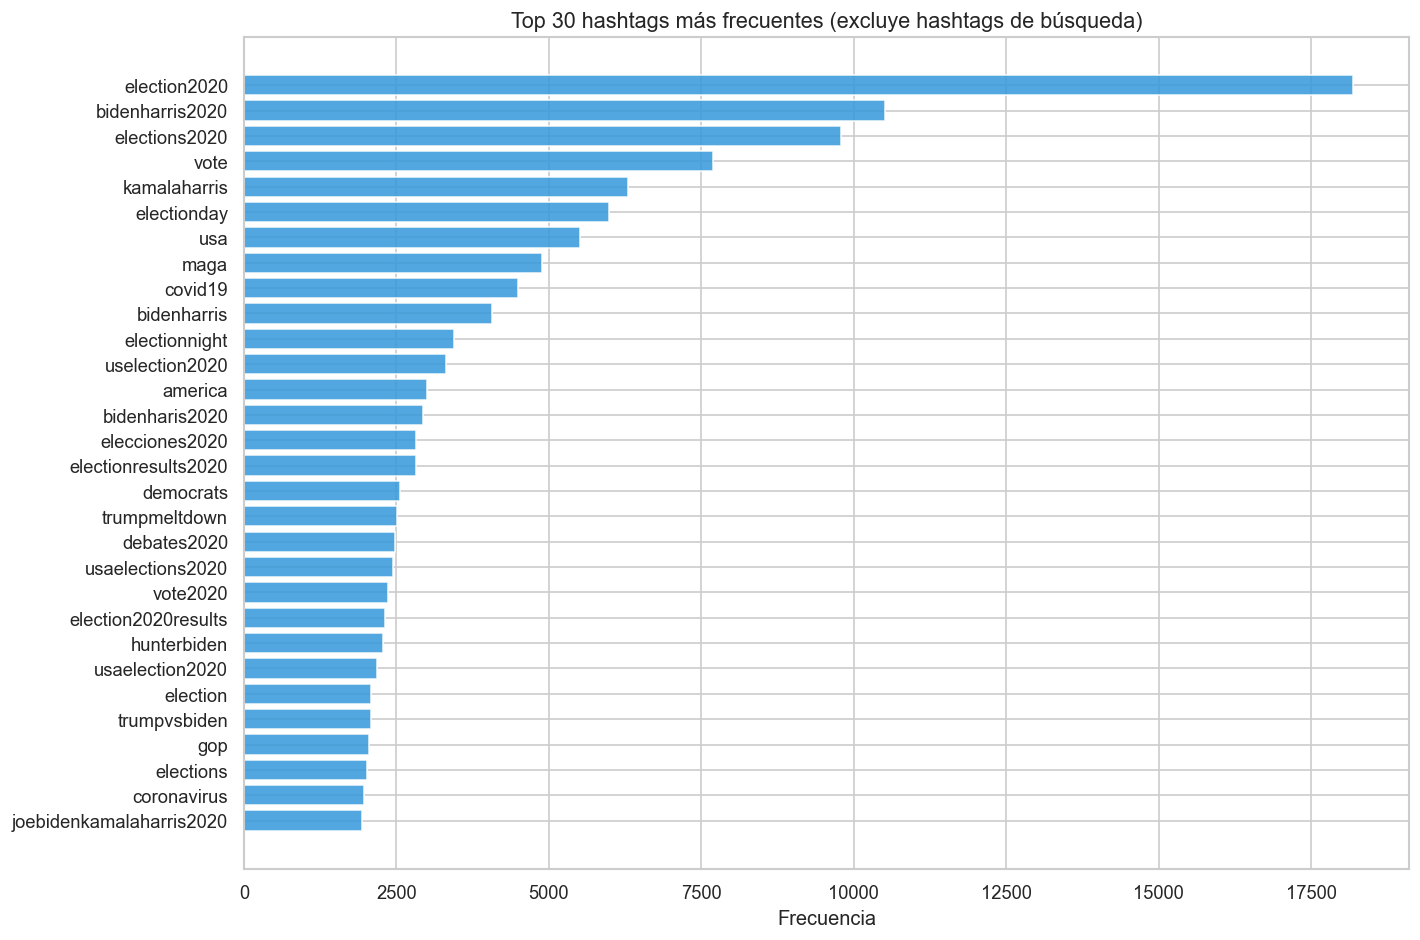

In [29]:
all_hashtags  = [ht for lista in df_sample['hashtags'] for ht in lista]
hashtag_counts = Counter(all_hashtags)
exclude = {'donaldtrump', 'trump', 'joebiden', 'biden', 'trump2020', 'biden2020'}
top_ht  = [(k, v) for k, v in hashtag_counts.most_common(50) if k not in exclude][:30]

labels, values = zip(*top_ht)
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(labels, values, color='#3498DB', alpha=0.85)
ax.invert_yaxis()
ax.set_title('Top 30 hashtags más frecuentes (excluye hashtags de búsqueda)', fontsize=13)
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_hashtags.png')
plt.show()

### 11.3 Distribución de likes y retweets

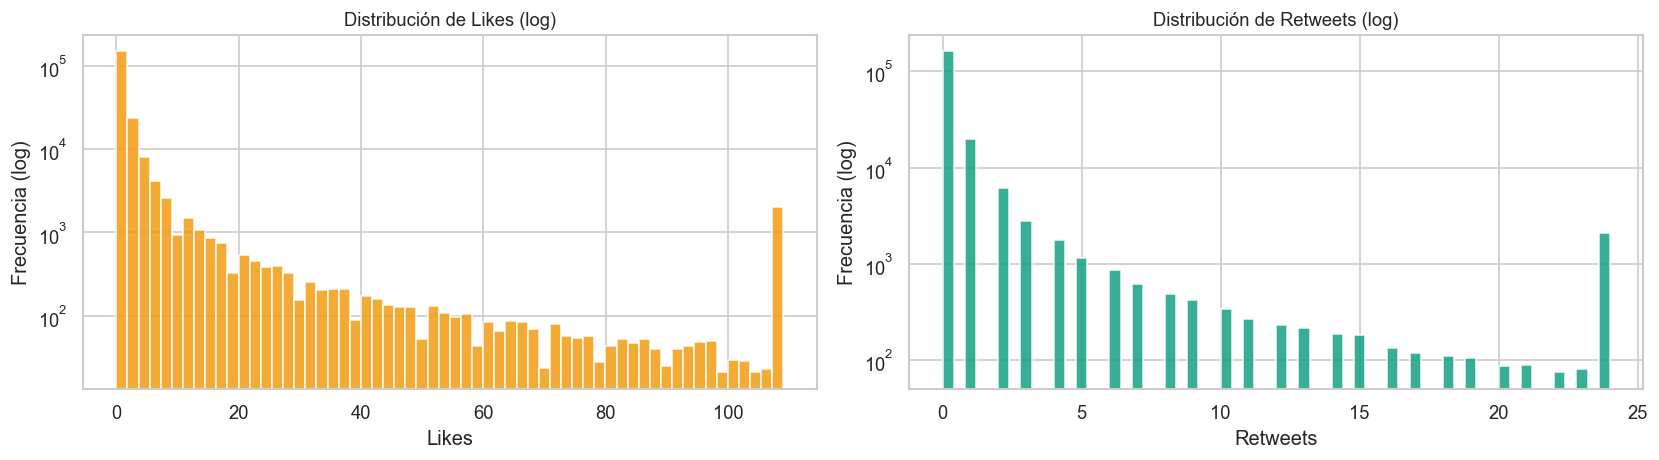

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color, label in [
    (axes[0], 'likes',         '#F39C12', 'Likes'),
    (axes[1], 'retweet_count', '#16A085', 'Retweets')
]:
    data      = df_sample[col].dropna()
    data_clip = data.clip(upper=data.quantile(0.99))
    ax.hist(data_clip, bins=60, color=color, edgecolor='white', alpha=0.85, log=True)
    ax.set_title(f'Distribución de {label} (log)', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia (log)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_likes_retweets.png')
plt.show()

## 12. Señales de coordinación preliminares
### 12.1 Cuentas que tuitean en múltiples ventanas de burst

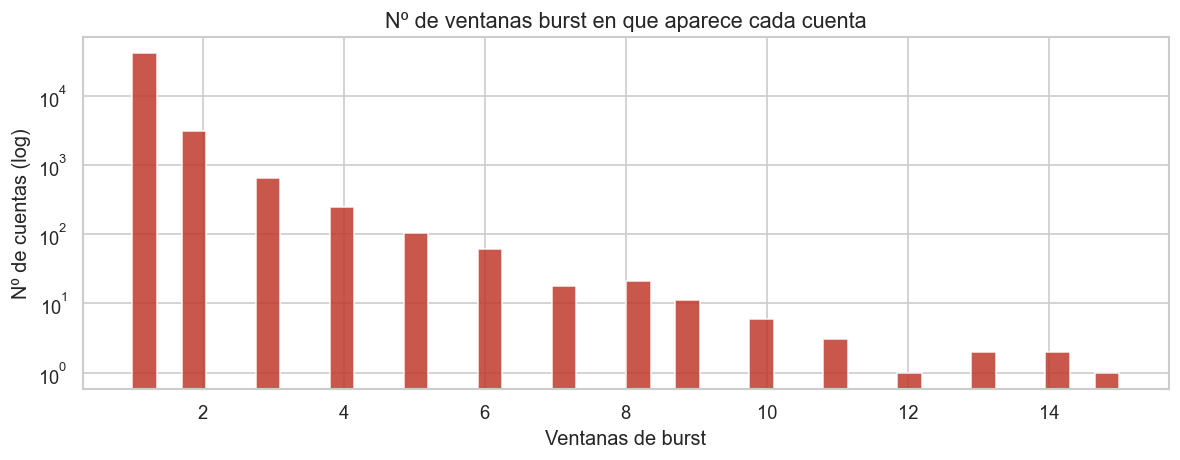

Cuentas en >= 5 ventanas de burst: 227
               user_id  burst_windows_count
 7.042226858621747e+17                   15
           231726084.0                   14
           786625296.0                   14
 8.743729821347594e+17                   13
          2373909360.0                   13
            92356864.0                   12
           152142811.0                   11
           161151263.0                   11
1.0247779165409649e+18                   11
            34639484.0                   10


In [31]:
burst_df = df_sample[df_sample['tweets_in_window'] >= p95]
burst_user_count = burst_df.groupby('user_id')['hour_window'].nunique().reset_index()
burst_user_count.columns = ['user_id', 'burst_windows_count']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(burst_user_count['burst_windows_count'], bins=40, color='#C0392B', edgecolor='white', alpha=0.85, log=True)
ax.set_title('Nº de ventanas burst en que aparece cada cuenta', fontsize=13)
ax.set_xlabel('Ventanas de burst')
ax.set_ylabel('Nº de cuentas (log)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_cuentas_burst.png')
plt.show()

multi_burst = burst_user_count[burst_user_count['burst_windows_count'] >= 5]
print(f'Cuentas en >= 5 ventanas de burst: {len(multi_burst):,}')
print(burst_user_count.sort_values('burst_windows_count', ascending=False).head(10).to_string(index=False))

### 12.2 Correlación entre variables numéricas

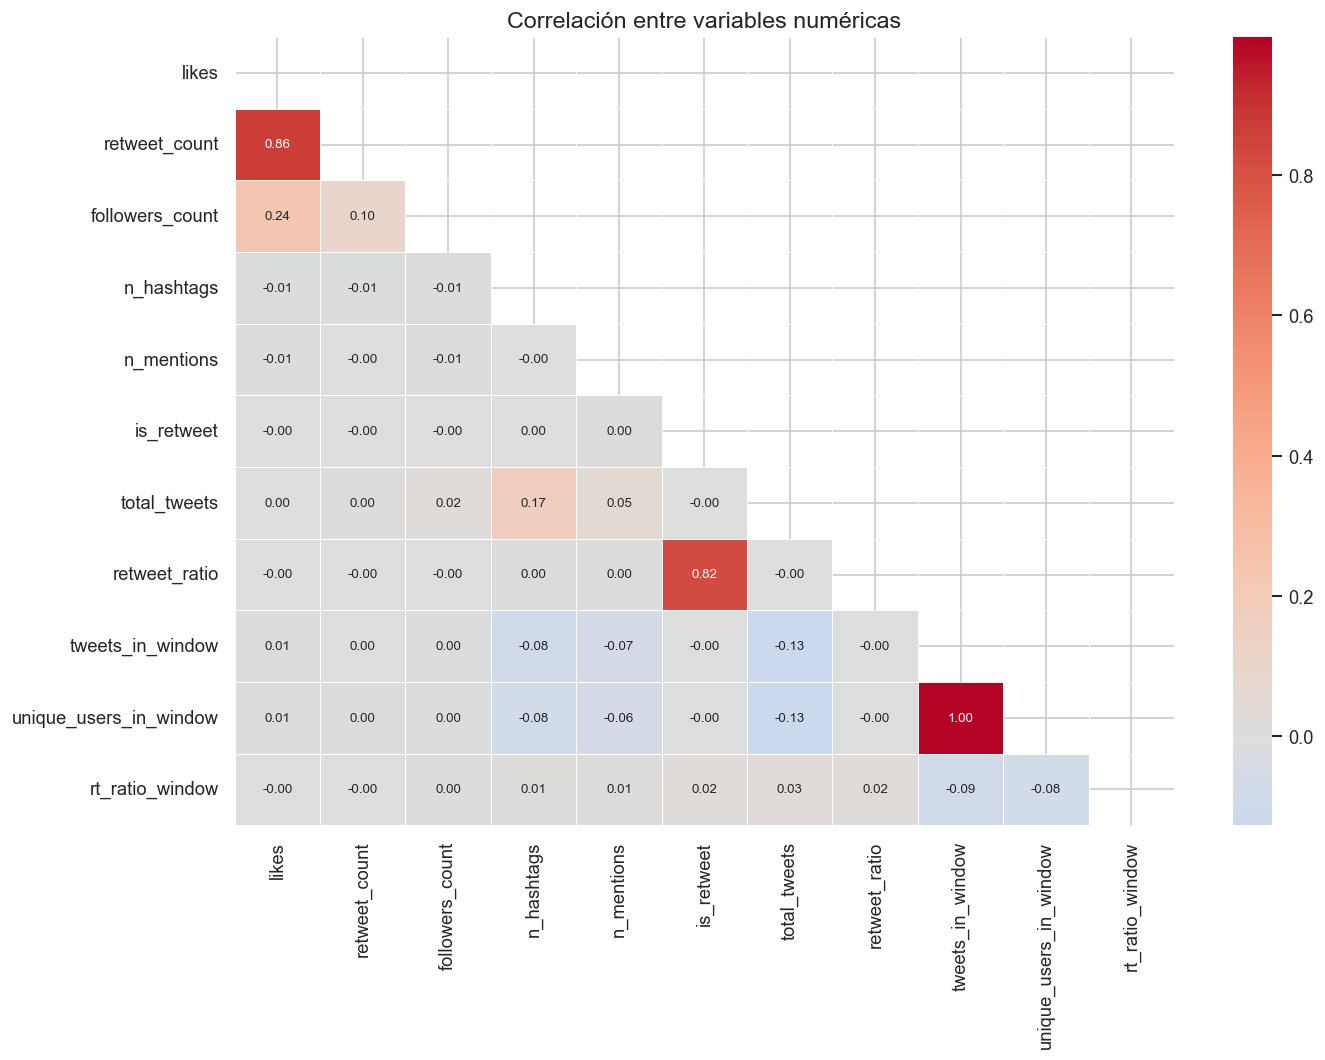

In [32]:
corr_cols = [c for c in [
    'likes', 'retweet_count', 'followers_count', 'n_hashtags',
    'n_mentions', 'is_retweet', 'total_tweets', 'retweet_ratio',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window'
] if c in df_sample.columns]

corr = df_sample[corr_cols].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlación entre variables numéricas', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_correlacion.png')
plt.show()

### 12.3 Actividad de las top 10 cuentas por volumen

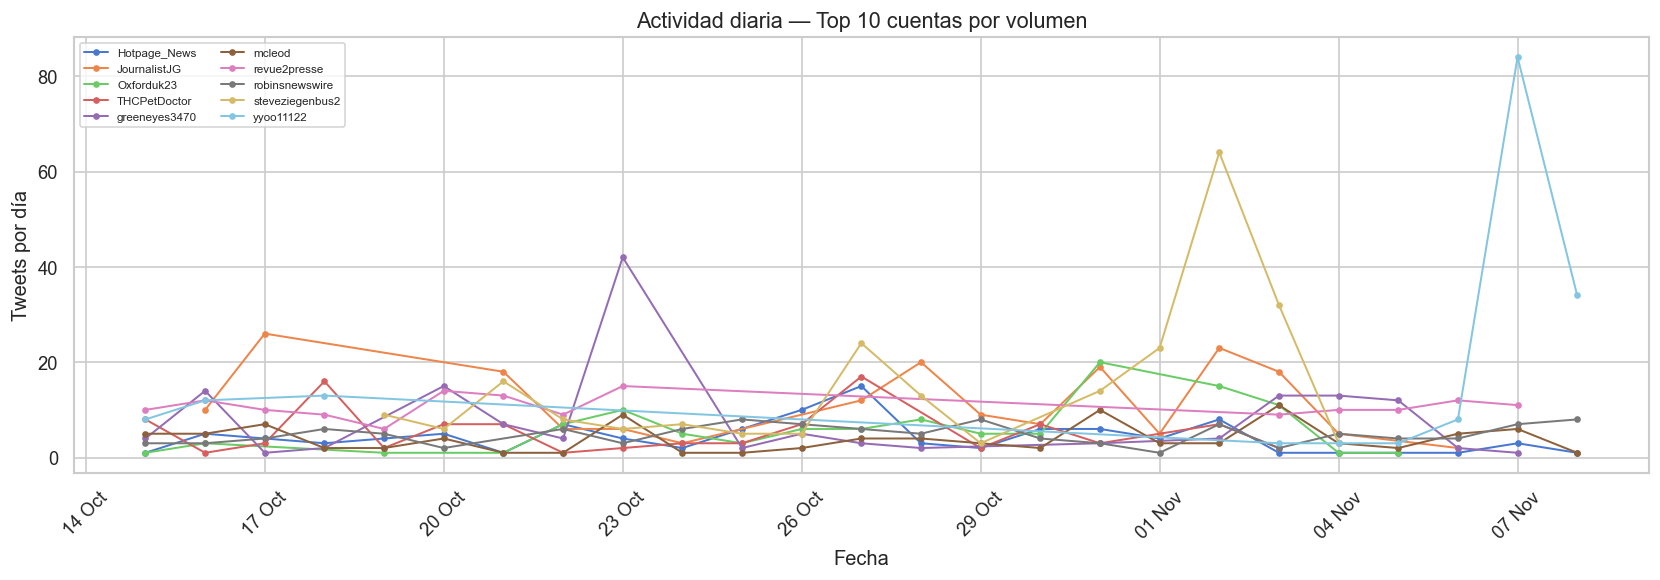

In [33]:
top_users  = df_sample.groupby('user_id').size().nlargest(10).index
top_df     = df_sample[df_sample['user_id'].isin(top_users)].copy()
top_df['user_label'] = top_df['user_screen_name'].fillna(top_df['user_id'].astype(str))

activity = top_df.groupby(['user_label', 'date']).size().reset_index(name='tweets')
activity['date'] = pd.to_datetime(activity['date'])

fig, ax = plt.subplots(figsize=(14, 5))
for user in activity['user_label'].unique():
    d = activity[activity['user_label'] == user]
    ax.plot(d['date'], d['tweets'], marker='o', markersize=3, linewidth=1.2, label=str(user))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Actividad diaria — Top 10 cuentas por volumen', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Tweets por día')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_top_cuentas_actividad.png')
plt.show()

---
## Pendientes
- [ ] Completar tabla de hallazgos con observaciones reales
- [ ] Integrar `bot_detection_data.csv` en A6
- [ ] Definir umbral definitivo de burst (P95 vs P99)
- [ ] Pasar `burst_windows` y `multi_burst` como insumo a A5

ORIGINAL DATAFRAME:
Shape: (20000, 37)

Carga de modelo: all-MiniLM-L6-v2


Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 4844.18it/s]


Creando embeddings 20000


Batches: 100%|███████████████████████████████████████████████████████████████████████| 157/157 [00:54<00:00,  2.86it/s]


Embeddings creados: shape (20000, 384)
Dataset grande (20000 filas), usando muestra de 5000 para similitud...
Matriz de similitud por coseno de 5000 items...
Generado 20 pares

Top 5 similar pairs:
  Row 143 <-> Row 2047: 1.0000
    "lhumanite"
    "lhumanite"

  Row 235 <-> Row 1292: 1.0000
    "ધયનથ તકણ જરદર કરએટવટ"
    "𝐋𝐌𝐀𝐇𝐄𝐉𝐄𝐇𝐄𝐉𝐔𝐄𝐉 𝐥𝐞𝐚𝐯𝐞 𝐍𝐞𝐯𝐚𝐝𝐚 𝐚𝐥𝐨𝐧𝐞"

  Row 276 <-> Row 3685: 1.0000
    "prove"
    "prove"

  Row 1809 <-> Row 4285: 1.0000
    "sim"
    "sim"

  Row 138 <-> Row 2485: 1.0000
    "આપણ અમક જતવ કરત ટરમપ હરવથ એટલ શકય"
    "ഇലകടറല വടടകളല ബഡന മനനലങകല കടതത മലസര സസഥനങങളല നരണയകമവനന"


--- KMeans ---
KMeans: 8 clusters

--- HDBSCAN ---
HDBSCAN: 3 clusters + 12399 noise

--- Agglomerative clustering ---
Numero de clusters: 2
Agglomerative: 2 clusters

--- Métricas de clustering ---
kmeans          | k=  8 | Sil=0.1077 | DB=4.0516 | CH=683.5
hdbscan         | k=  3 | Sil=0.2265 | DB=1.0227 | CH=973.2
agglomerative   | k=  2 | Sil=0.0774 | DB=1.0350 | CH=1803.3


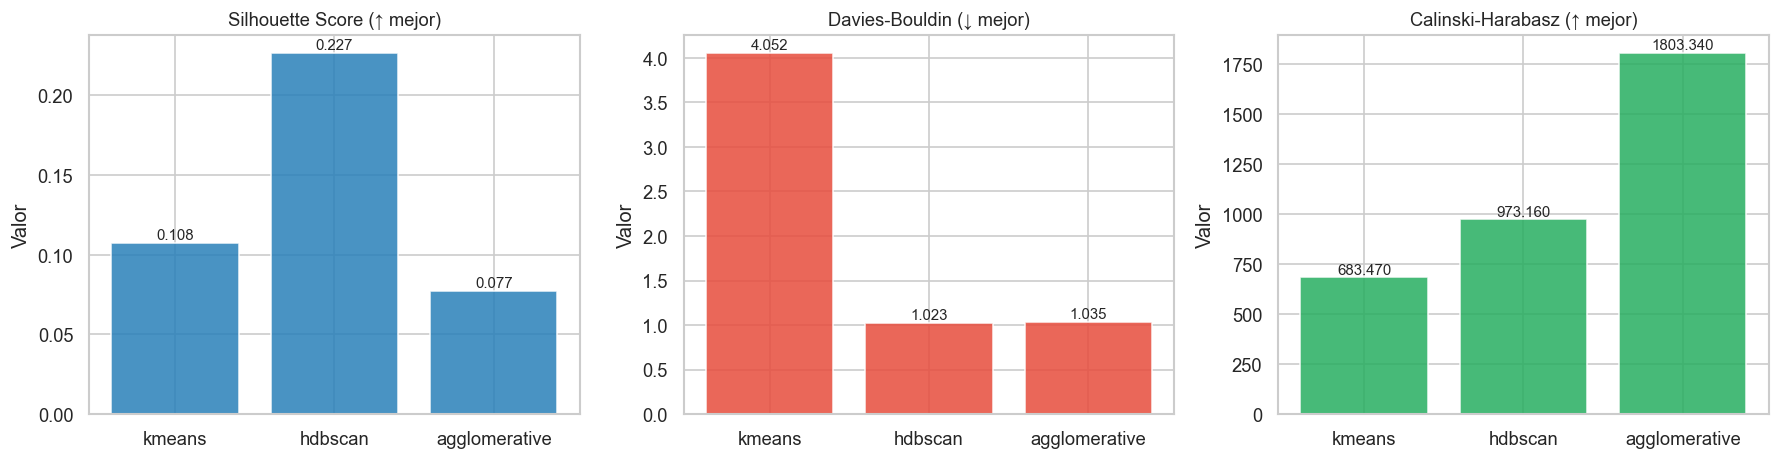

       Método  Clusters  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
       kmeans         8        0.1077            4.0516               683.47
      hdbscan         3        0.2265            1.0227               973.16
agglomerative         2        0.0774            1.0350              1803.34
Proyeccion t-SNE ...


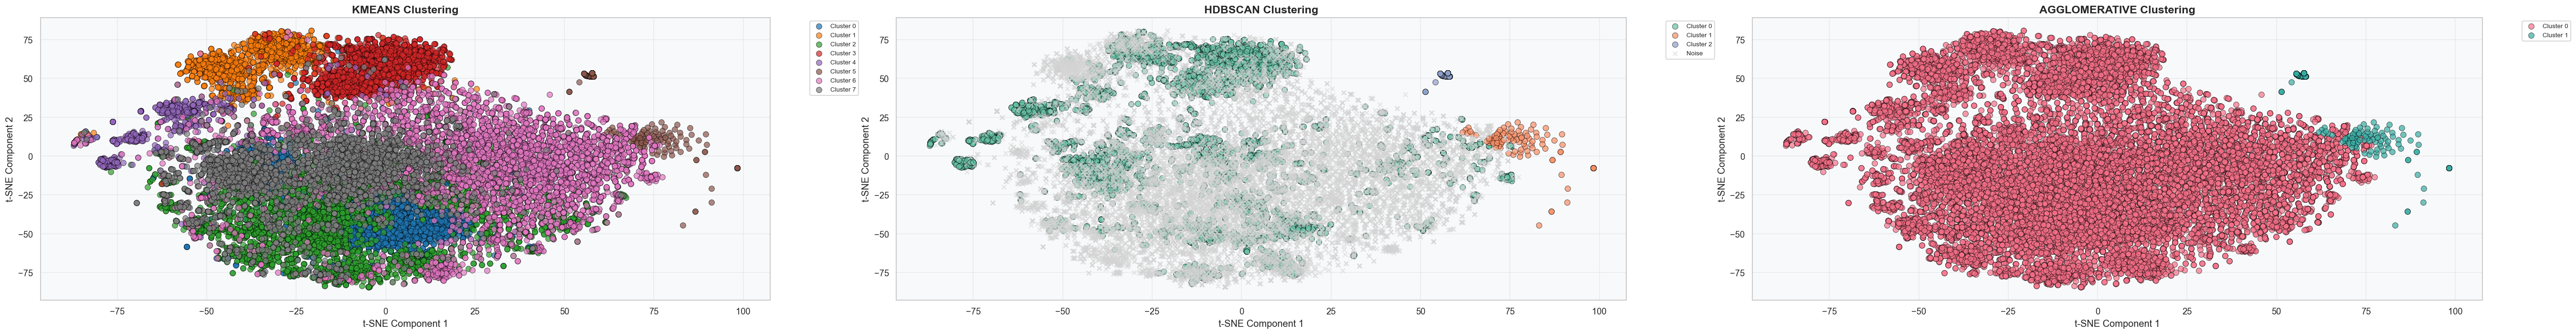


CLUSTER STATISTICS

KMEANS:
  Cluster 0: 2372 samples (11.9%)
  Cluster 1: 1575 samples (7.9%)
  Cluster 2: 3665 samples (18.3%)
  Cluster 3: 1803 samples (9.0%)
  Cluster 4: 788 samples (3.9%)
  Cluster 5: 1935 samples (9.7%)
  Cluster 6: 4734 samples (23.7%)
  Cluster 7: 3128 samples (15.6%)

HDBSCAN:
  Noise: 12399 samples (62.0%)
  Cluster 0: 5666 samples (28.3%)
  Cluster 1: 111 samples (0.6%)
  Cluster 2: 1824 samples (9.1%)

AGGLOMERATIVE:
  Cluster 0: 18065 samples (90.3%)
  Cluster 1: 1935 samples (9.7%)


In [43]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import hdbscan
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Parametros globales
KMEANS_PARAMS = {
    'n_clusters': 8,
    'random_state': 42,
    'n_init': 10,
    'max_iter': 300
}

HDBSCAN_PARAMS = {
    'min_cluster_size': 50, 
    'min_samples': 5,
    'metric': 'euclidean',
    'cluster_selection_method': 'eom',
    'prediction_data': True
}

AGGLOMERATIVE_PARAMS = {
    'n_clusters': None,
    'linkage': 'ward',
    'metric': 'euclidean'
}

TSNE_PARAMS = {
    'n_components': 2,
    'perplexity': 30, 
    'early_exaggeration': 12,
    'learning_rate': 'auto',
    'max_iter': 1000,
    'random_state': 42,
    'init': 'pca'
}


def create_embeddings(df: pd.DataFrame, text_column: str = 'text_clean',
                      model_name: str = 'all-MiniLM-L6-v2') -> pd.DataFrame:
    print(f"Carga de modelo: {model_name}")
    model = SentenceTransformer(model_name)
    print(f"Creando embeddings {len(df)}")
    embeddings = model.encode(df[text_column].tolist(), show_progress_bar=True, batch_size=128)
    df = df.copy()
    df['embeddings'] = list(embeddings)
    print(f"Embeddings creados: shape {embeddings.shape}")
    return df


def generate_similarity_pairs(df: pd.DataFrame, embedding_column: str = 'embeddings',
                               top_k: Optional[int] = None,
                               threshold: Optional[float] = None,
                               sim_sample: int = 2000) -> List[Tuple[int, int, float]]:
    """
    Calcula similitud coseno sobre una muestra para evitar MemoryError.
    sim_sample: máximo de filas a usar para la matriz (default 2000)
    """
    if len(df) > sim_sample:
        print(f"Dataset grande ({len(df)} filas), usando muestra de {sim_sample} para similitud...")
        df_sim = df.sample(sim_sample, random_state=42).reset_index(drop=True)
    else:
        df_sim = df.reset_index(drop=True)

    embeddings = np.array(df_sim[embedding_column].tolist())
    print(f"Matriz de similitud por coseno de {len(embeddings)} items...")
    similarity_matrix = cosine_similarity(embeddings)

    pairs = []
    n = len(df_sim)
    for i in range(n):
        for j in range(i + 1, n):
            sim = similarity_matrix[i, j]
            if threshold is not None and sim < threshold:
                continue
            pairs.append((i, j, sim))

    pairs.sort(key=lambda x: x[2], reverse=True)
    if top_k is not None:
        pairs = pairs[:top_k]

    print(f"Generado {len(pairs)} pares")
    return pairs, df_sim


def apply_clustering(df: pd.DataFrame, embedding_column: str = 'embeddings',
                     methods: List[str] = ['kmeans', 'hdbscan', 'agglomerative']) -> pd.DataFrame:
    df = df.copy()
    embeddings = np.array(df[embedding_column].tolist())

    if 'kmeans' in methods:
        print("\n--- KMeans ---")
        n_clusters = KMEANS_PARAMS['n_clusters']
        if n_clusters is None:
            n_clusters = auto_determine_kmeans_clusters(embeddings)
            print(f"Numero de clusters: {n_clusters}")
        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=KMEANS_PARAMS['random_state'],
            n_init=KMEANS_PARAMS['n_init'],
            max_iter=KMEANS_PARAMS['max_iter']
        )
        df['cluster_kmeans'] = kmeans.fit_predict(embeddings)
        print(f"KMeans: {n_clusters} clusters")

    if 'hdbscan' in methods:
        print("\n--- HDBSCAN ---")
        min_cluster_size = HDBSCAN_PARAMS['min_cluster_size']
        min_samples = HDBSCAN_PARAMS['min_samples'] or min_cluster_size
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric=HDBSCAN_PARAMS['metric'],
            cluster_selection_method=HDBSCAN_PARAMS['cluster_selection_method'],
            prediction_data=HDBSCAN_PARAMS['prediction_data']
        )
        df['cluster_hdbscan'] = clusterer.fit_predict(embeddings)
        n_clusters_hdb = len(set(df['cluster_hdbscan'])) - (1 if -1 in df['cluster_hdbscan'].values else 0)
        n_noise = (df['cluster_hdbscan'] == -1).sum()
        print(f"HDBSCAN: {n_clusters_hdb} clusters + {n_noise} noise")

    if 'agglomerative' in methods:
        print("\n--- Agglomerative clustering ---")
        from sklearn.cluster import AgglomerativeClustering
        n_clusters = AGGLOMERATIVE_PARAMS['n_clusters']
        if n_clusters is None:
            n_clusters = auto_determine_kmeans_clusters(embeddings)
            print(f"Numero de clusters: {n_clusters}")
        agglomerative = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=AGGLOMERATIVE_PARAMS['linkage'],
            metric=AGGLOMERATIVE_PARAMS['metric']
        )
        df['cluster_agglomerative'] = agglomerative.fit_predict(embeddings)
        print(f"Agglomerative: {n_clusters} clusters")

    return df


def auto_determine_kmeans_clusters(embeddings, max_clusters=15):
    inertias = []
    K = range(2, min(max_clusters, len(embeddings) - 1))
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(embeddings)
        inertias.append(kmeans.inertia_)
    if len(inertias) > 2:
        diffs = np.diff(inertias)
        diffs2 = np.diff(diffs)
        elbow = np.argmax(diffs2) + 2
        return min(max(2, elbow), max_clusters)
    else:
        return min(5, len(embeddings) // 10 + 2)


def compute_clustering_metrics(df: pd.DataFrame, embedding_column: str = 'embeddings',
                                methods: List[str] = ['kmeans', 'hdbscan', 'agglomerative']):
    """Calcula Silhouette, Davies-Bouldin y Calinski-Harabasz para cada método."""
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

    embeddings = np.array(df[embedding_column].tolist())
    results = []

    for method in methods:
        col = f'cluster_{method}'
        if col not in df.columns:
            continue
        labels = df[col].values
        mask   = labels != -1
        labels_valid = labels[mask]
        emb_valid    = embeddings[mask]
        n_clusters   = len(set(labels_valid))

        if n_clusters < 2:
            print(f'{method}: menos de 2 clusters, métricas no calculables')
            results.append({'Método': method, 'Clusters': n_clusters,
                            'Silhouette': None, 'Davies-Bouldin': None, 'Calinski-Harabasz': None})
            continue

        sil = silhouette_score(emb_valid, labels_valid, sample_size=3000, random_state=42)
        db  = davies_bouldin_score(emb_valid, labels_valid)
        ch  = calinski_harabasz_score(emb_valid, labels_valid)

        results.append({
            'Método': method,
            'Clusters': n_clusters,
            'Silhouette ↑': round(sil, 4),
            'Davies-Bouldin ↓': round(db, 4),
            'Calinski-Harabasz ↑': round(ch, 2)
        })
        print(f'{method:15s} | k={n_clusters:3d} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}')

    metrics_df = pd.DataFrame(results)

    # Gráfico comparativo
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, color, titulo in [
        (axes[0], 'Silhouette ↑',        '#2980B9', 'Silhouette Score (↑ mejor)'),
        (axes[1], 'Davies-Bouldin ↓',     '#E74C3C', 'Davies-Bouldin (↓ mejor)'),
        (axes[2], 'Calinski-Harabasz ↑',  '#27AE60', 'Calinski-Harabasz (↑ mejor)'),
    ]:
        if col not in metrics_df.columns:
            continue
        vals = metrics_df[col].astype(float)
        ax.bar(metrics_df['Método'], vals, color=color, alpha=0.85, edgecolor='white')
        ax.set_title(titulo, fontsize=11)
        ax.set_ylabel('Valor')
        for i, v in enumerate(vals):
            if not np.isnan(v):
                ax.text(i, v + vals.max() * 0.01, f'{v:.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('outputs/clustering_metricas.png')
    plt.show()

    return metrics_df


def visualize_clusters(df: pd.DataFrame, embedding_column: str = 'embeddings',
                       methods_to_plot: List[str] = ['kmeans', 'hdbscan', 'agglomerative'],
                       figsize: Tuple[int, int] = (15, 6)):
    embeddings = np.array(df[embedding_column].tolist())
    print("Proyeccion t-SNE ...")
    tsne = TSNE(
        n_components=TSNE_PARAMS['n_components'],
        random_state=TSNE_PARAMS['random_state'],
        perplexity=min(TSNE_PARAMS['perplexity'], len(df) - 1),
        max_iter=TSNE_PARAMS['max_iter']
    )
    embeddings_2d = tsne.fit_transform(embeddings)

    n_methods = len(methods_to_plot)
    fig, axes = plt.subplots(1, n_methods, figsize=(figsize[0] * n_methods, figsize[1]))
    if n_methods == 1:
        axes = [axes]

    for idx, method in enumerate(methods_to_plot):
        cluster_col = f'cluster_{method}'
        if cluster_col not in df.columns:
            print(f"Warning: {cluster_col} not found")
            continue

        cluster_labels = df[cluster_col].values
        unique_clusters = sorted(set(cluster_labels))
        noise_mask = pd.Series([False] * len(df))

        if method == 'hdbscan':
            noise_mask = df[cluster_col] == -1
            unique_clusters = [c for c in unique_clusters if c != -1]

        palette_map = {'kmeans': 'tab10', 'hdbscan': 'Set2', 'agglomerative': 'husl'}
        color_palette = sns.color_palette(palette_map.get(method, 'tab10'), n_colors=max(len(unique_clusters), 1))
        ax = axes[idx]

        for i, cluster_id in enumerate(unique_clusters):
            mask = df[cluster_col] == cluster_id
            ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                       c=[color_palette[i % len(color_palette)]], label=f'Cluster {cluster_id}',
                       alpha=0.7, s=50, edgecolors='black', linewidth=0.5)

        if method == 'hdbscan' and noise_mask.any():
            ax.scatter(embeddings_2d[noise_mask, 0], embeddings_2d[noise_mask, 1],
                       c='lightgray', label='Noise', alpha=0.5, s=30, marker='x')

        ax.set_title(f'{method.upper()} Clustering', fontsize=14, fontweight='bold')
        ax.set_xlabel('t-SNE Component 1')
        ax.set_ylabel('t-SNE Component 2')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#f8f9fa')

    plt.tight_layout()
    plt.savefig('outputs/clustering_tsne.png', bbox_inches='tight')
    plt.show()

    print("\n" + "=" * 50)
    print("CLUSTER STATISTICS")
    print("=" * 50)
    for method in methods_to_plot:
        cluster_col = f'cluster_{method}'
        if cluster_col in df.columns:
            print(f"\n{method.upper()}:")
            cluster_counts = df[cluster_col].value_counts().sort_index()
            total_samples = len(df)
            for cluster_id, count in cluster_counts.items():
                pct = (count / total_samples) * 100
                label = "Noise" if (method == 'hdbscan' and cluster_id == -1) else f"Cluster {cluster_id}"
                print(f"  {label}: {count} samples ({pct:.1f}%)")

    return fig


def example_usage(df):
    print("ORIGINAL DATAFRAME:")
    print(f"Shape: {df.shape}")
    print("\n" + "=" * 50)

    df = create_embeddings(df, text_column='text_clean', model_name='all-MiniLM-L6-v2')

    similarity_pairs, df_sim = generate_similarity_pairs(df, top_k=20, sim_sample=5000)
    print("\nTop 5 similar pairs:")
    for i, j, sim in similarity_pairs[:5]:
        print(f"  Row {i} <-> Row {j}: {sim:.4f}")
        print(f"    \"{df_sim.iloc[i]['text_clean'][:80]}\"")
        print(f"    \"{df_sim.iloc[j]['text_clean'][:80]}\"")
        print()

    df = apply_clustering(df, methods=['kmeans', 'hdbscan', 'agglomerative'])

    print("\n--- Métricas de clustering ---")
    metrics_df = compute_clustering_metrics(df, methods=['kmeans', 'hdbscan', 'agglomerative'])
    print(metrics_df.to_string(index=False))

    visualize_clusters(df, methods_to_plot=['kmeans', 'hdbscan', 'agglomerative'])

    return df, similarity_pairs


# ── Ejecutar sobre muestra reducida ──────────────────────────────────────────
CLUSTER_N = 20_000

trump_cl = df[df['candidate'] == 'trump'].sample(
    min(len(df[df['candidate'] == 'trump']), CLUSTER_N // 2), random_state=42)
biden_cl = df[df['candidate'] == 'biden'].sample(
    min(len(df[df['candidate'] == 'biden']), CLUSTER_N // 2), random_state=42)

df_cluster = pd.concat([trump_cl, biden_cl]).reset_index(drop=True)

df_result, pairs = example_usage(df_cluster)

Dataset cargado: 200,000 tweets
Distribución de clusters:
cluster_hdbscan
-1    192399
 0      5666
 1       111
 2      1824
Name: count, dtype: int64

Criterio 1 (cluster denso): 111 tweets
Criterio 2 (burst P95=38179): 13,117 tweets
Calculando similitud textual por ventana horaria...
Criterio 3 (similitud >= 0.8): 14,267 tweets

Orgánico (0):   196,812 (98.4%)
Sospechoso (1): 3,188 (1.6%)


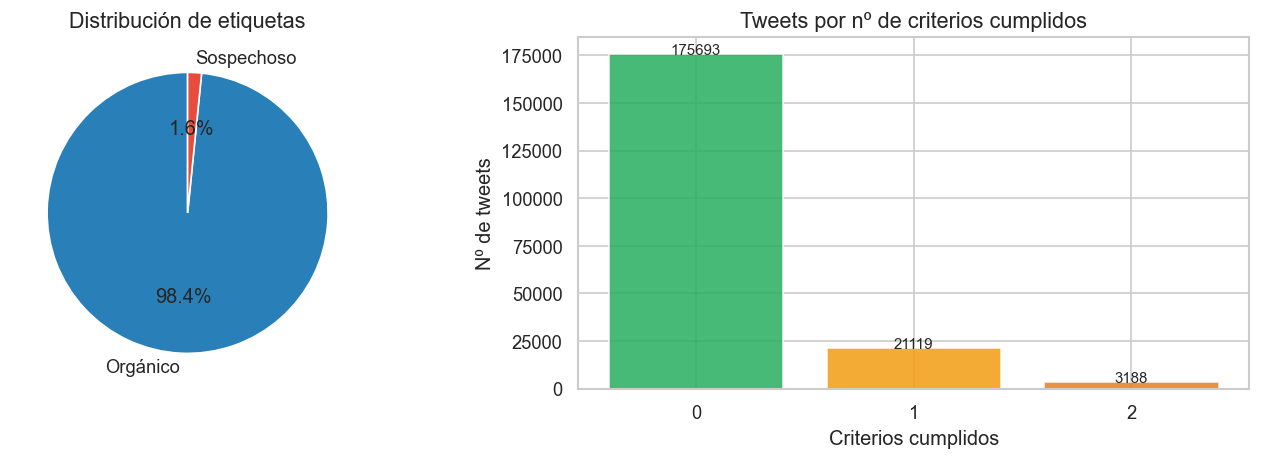

Features: ['followers_count', 'likes', 'retweet_count', 'n_hashtags', 'n_mentions', 'is_retweet', 'hour', 'day_of_week', 'account_age_days', 'total_tweets', 'retweet_ratio', 'avg_likes', 'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window']
Train: 160,000 | Test: 40,000
Sospechosos train: 2,550 (1.6%)
Sospechosos test:  638  (1.6%)

Entrenando Regresión Logística...
  Accuracy: 0.9512
  Precision: 0.2463
  Recall: 1.0
  F1-score: 0.3953
  ROC-AUC: 0.9733
  CV F1: 0.3911

Entrenando Random Forest...
  Accuracy: 0.9819
  Precision: 0.3195
  Recall: 0.1207
  F1-score: 0.1752
  ROC-AUC: 0.9774
  CV F1: 0.1927

Entrenando XGBoost...
  Accuracy: 0.9633
  Precision: 0.2653
  Recall: 0.7351
  F1-score: 0.3899
  ROC-AUC: 0.9779
  CV F1: 0.3873

=== Comparación de modelos ===
                     Accuracy  Precision  Recall  F1-score  ROC-AUC   CV F1
Regresión Logística    0.9512     0.2463  1.0000    0.3953   0.9733  0.3911
Random Forest          0.9819     0.3195  0.1207    0.1752  

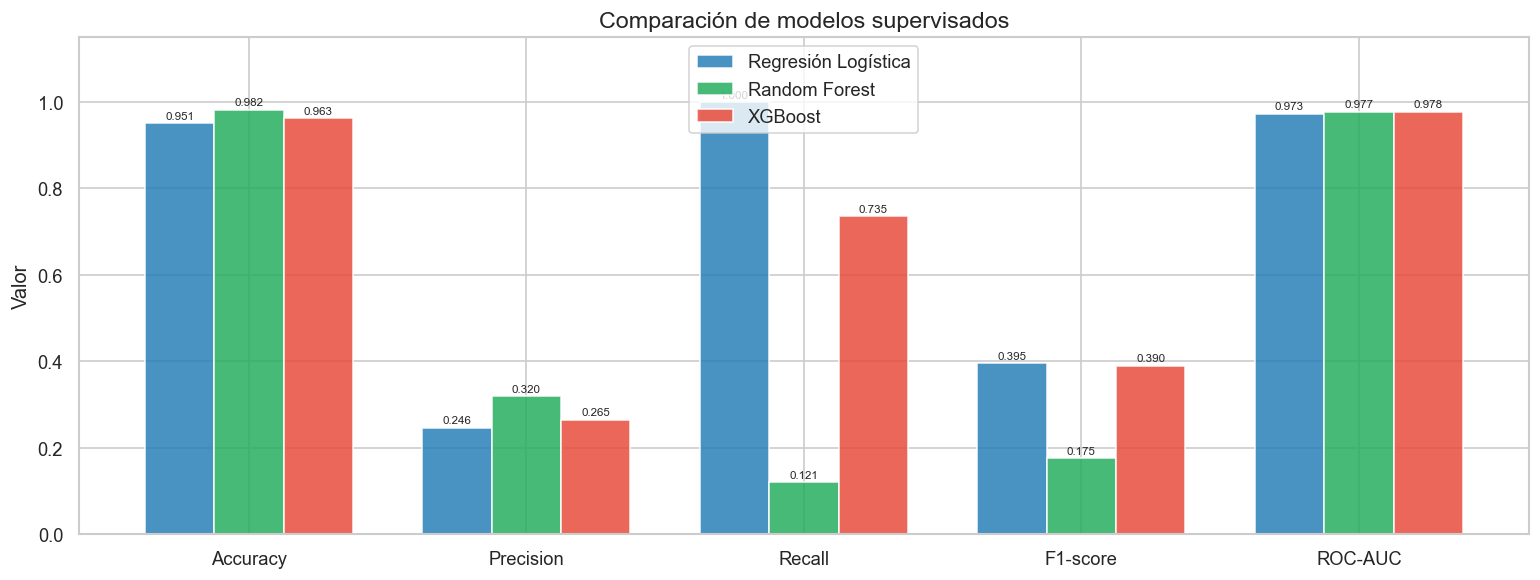

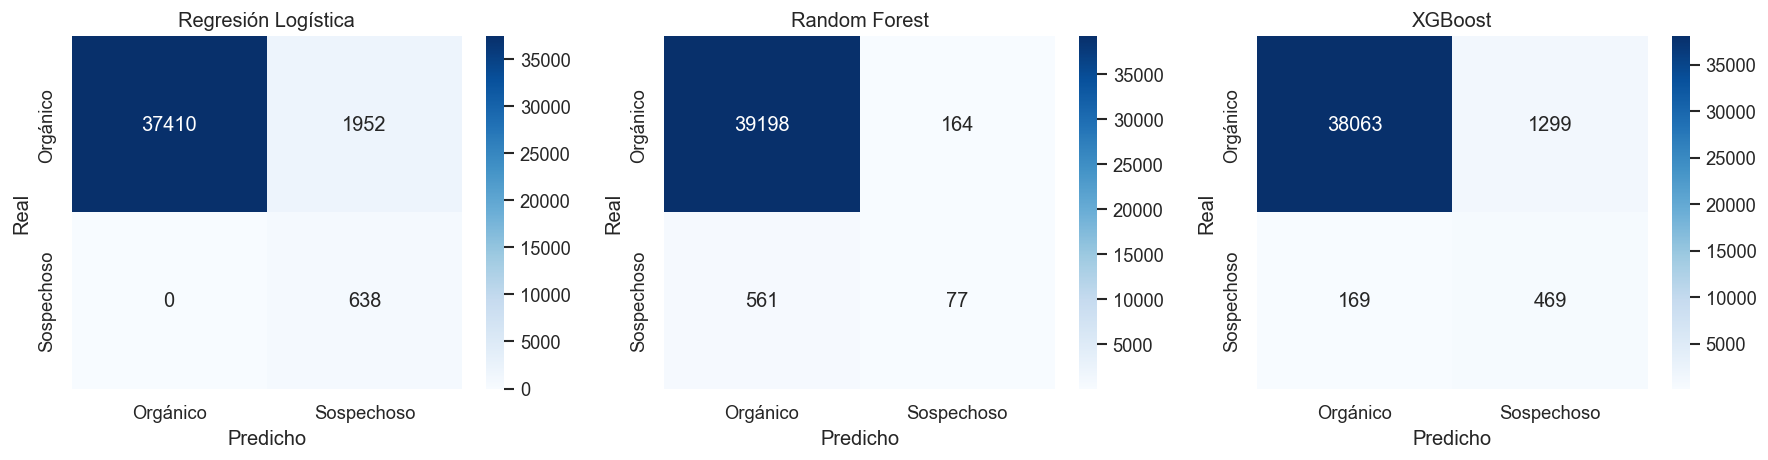

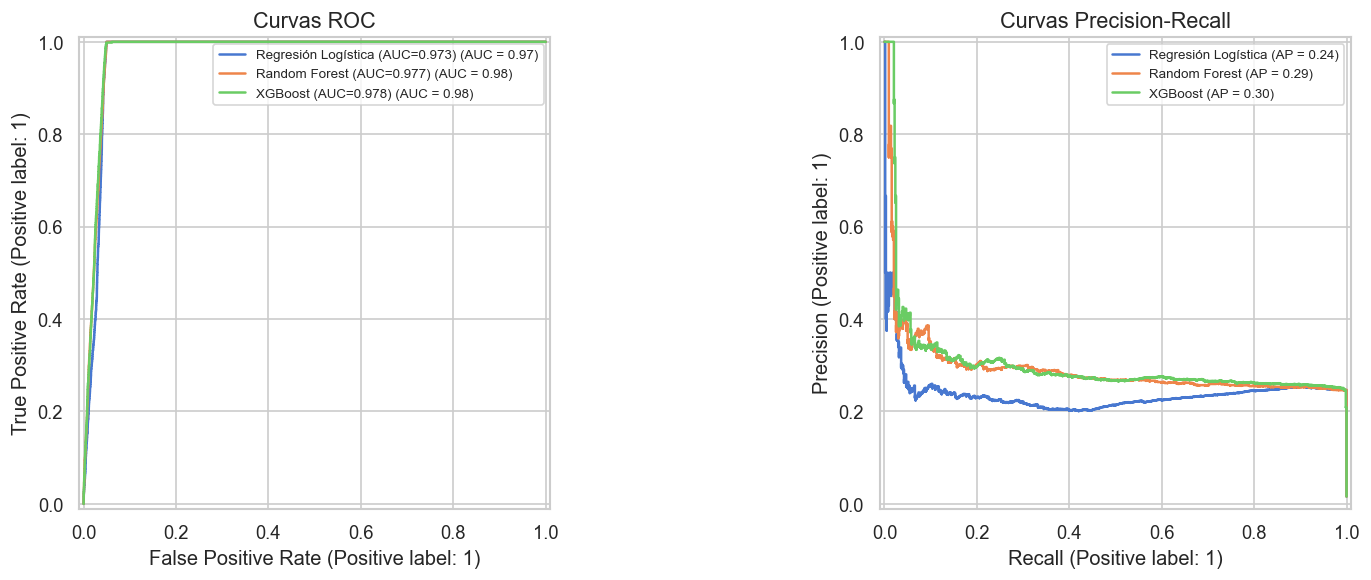

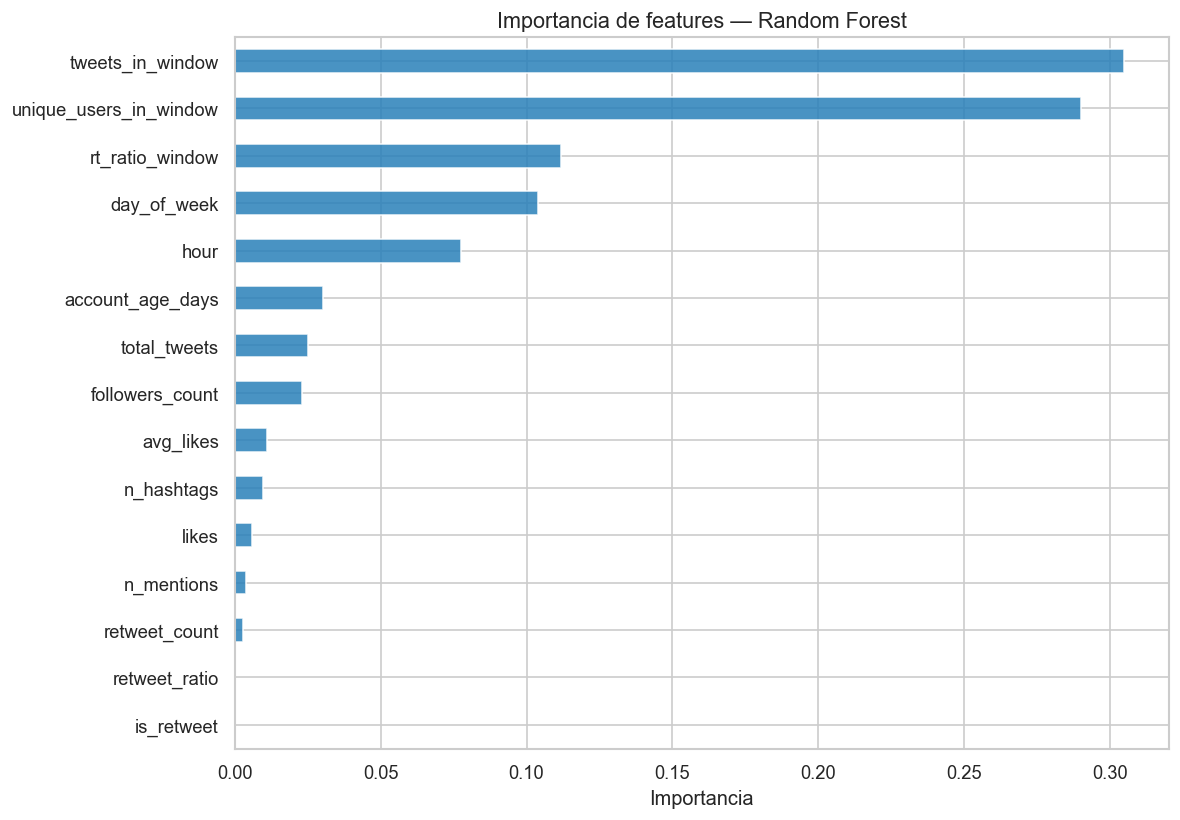


Mejor modelo: Regresión Logística
F1-score: 0.3953 | ROC-AUC: 0.9733

=== Classification Report ===
              precision    recall  f1-score   support

    Orgánico       1.00      0.95      0.97     39362
  Sospechoso       0.25      1.00      0.40       638

    accuracy                           0.95     40000
   macro avg       0.62      0.98      0.68     40000
weighted avg       0.99      0.95      0.97     40000


Tweets clasificados como sospechosos: 2,590
                                                                                                                                                                                                                                                                                                  text user_screen_name                created_at  pred_proba  criterios_cumplidos  tweets_in_window  retweet_ratio
                                                                                                                           

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import ast

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
OUTPUT_DIR = Path('outputs/')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── 1. Carga de datos ─────────────────────────────────────────────────────────
df = pd.read_csv(OUTPUT_DIR / 'df_processed_sample.csv', low_memory=False)
df['created_at']  = pd.to_datetime(df['created_at'],  utc=True, errors='coerce')
df['hour_window'] = pd.to_datetime(df['hour_window'], utc=True, errors='coerce')
for col in ['hashtags', 'mentions']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
print(f'Dataset cargado: {len(df):,} tweets')

# ── Unir cluster_hdbscan desde df_result (de A5) ─────────────────────────────
cluster_map = df_result[['tweet_id', 'cluster_hdbscan']].drop_duplicates()
df['tweet_id']          = df['tweet_id'].astype(str)
cluster_map['tweet_id'] = cluster_map['tweet_id'].astype(str)
df = df.merge(cluster_map, on='tweet_id', how='left')
df['cluster_hdbscan'] = df['cluster_hdbscan'].fillna(-1).astype(int)
print('Distribución de clusters:')
print(df['cluster_hdbscan'].value_counts().sort_index())

# ── 2. Etiquetado ─────────────────────────────────────────────────────────────

# Criterio 1: cluster HDBSCAN (cluster 1 = más denso y pequeño)
df['crit_cluster'] = (df['cluster_hdbscan'] == 1).astype(int)
print(f'\nCriterio 1 (cluster denso): {df["crit_cluster"].sum():,} tweets')

# Criterio 2: burst temporal
p95 = df['tweets_in_window'].quantile(0.95)
df['crit_burst'] = (df['tweets_in_window'] >= p95).astype(int)
print(f'Criterio 2 (burst P95={p95:.0f}): {df["crit_burst"].sum():,} tweets')

# Criterio 3: similitud textual >= 0.8 por ventana horaria
print('Calculando similitud textual por ventana horaria...')
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df['text_clean'].fillna(''))
SIM_THRESHOLD    = 0.8
high_sim_indices = set()
for window in df['hour_window'].unique():
    idx = df[df['hour_window'] == window].index.tolist()
    if len(idx) < 2:
        continue
    sim = cosine_similarity(tfidf_matrix[idx])
    np.fill_diagonal(sim, 0)
    for p, q in np.argwhere(sim >= SIM_THRESHOLD):
        high_sim_indices.add(idx[p])
        high_sim_indices.add(idx[q])
df['crit_similitud'] = 0
df.loc[list(high_sim_indices), 'crit_similitud'] = 1
print(f'Criterio 3 (similitud >= 0.8): {df["crit_similitud"].sum():,} tweets')

# Etiqueta final
df['criterios_cumplidos'] = df['crit_cluster'] + df['crit_burst'] + df['crit_similitud']
df['label'] = (df['criterios_cumplidos'] >= 2).astype(int)
print(f'\nOrgánico (0):   {(df["label"]==0).sum():,} ({(df["label"]==0).mean()*100:.1f}%)')
print(f'Sospechoso (1): {(df["label"]==1).sum():,} ({(df["label"]==1).mean()*100:.1f}%)')
df.to_csv(OUTPUT_DIR / 'df_etiquetado.csv', index=False)

# Visualización etiquetas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['label'].value_counts()
axes[0].pie(counts, labels=['Orgánico', 'Sospechoso'], autopct='%1.1f%%',
            colors=['#2980B9', '#E74C3C'], startangle=90)
axes[0].set_title('Distribución de etiquetas', fontsize=13)
crit_counts = df['criterios_cumplidos'].value_counts().sort_index()
axes[1].bar(crit_counts.index.astype(str), crit_counts.values,
            color=['#27AE60', '#F39C12', '#E67E22', '#E74C3C'], alpha=0.85)
axes[1].set_title('Tweets por nº de criterios cumplidos', fontsize=13)
axes[1].set_xlabel('Criterios cumplidos')
axes[1].set_ylabel('Nº de tweets')
for i, v in enumerate(crit_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_distribucion_etiquetas.png')
plt.show()

# ── 3. Features ───────────────────────────────────────────────────────────────
FEATURE_COLS = [c for c in [
    'followers_count', 'likes', 'retweet_count',
    'n_hashtags', 'n_mentions', 'is_retweet',
    'hour', 'day_of_week', 'account_age_days',
    'total_tweets', 'retweet_ratio', 'avg_likes',
    'tweets_in_window', 'unique_users_in_window', 'rt_ratio_window'
    # ← se eliminan crit_cluster, crit_burst, crit_similitud
] if c in df.columns]
print(f'Features: {FEATURE_COLS}')

X        = df[FEATURE_COLS].fillna(0).values
y        = df['label'].values
X_scaled = MinMaxScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Sospechosos train: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'Sospechosos test:  {y_test.sum():,}  ({y_test.mean()*100:.1f}%)')

# ── 4. Entrenamiento ──────────────────────────────────────────────────────────
models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss',
                                         scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
}
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'\nEntrenando {name}...')
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
        'CV F1':     round(cross_val_score(model, X_scaled, y, cv=cv, scoring='f1').mean(), 4),
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba
    }
    for k, v in results[name].items():
        if k not in ['model', 'y_pred', 'y_proba']:
            print(f'  {k}: {v}')

# ── 5. Comparación de modelos ─────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ['model', 'y_pred', 'y_proba']}
    for name, vals in results.items()
}).T
print('\n=== Comparación de modelos ===')
print(metrics_df.to_string())
metrics_df.to_csv(OUTPUT_DIR / 'a6_metricas_modelos.csv')

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.25
colors = ['#2980B9', '#27AE60', '#E74C3C']
fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, vals) in enumerate(results.items()):
    bars = ax.bar(x + i*width, [vals[m] for m in metric_cols], width,
                  label=name, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, [vals[m] for m in metric_cols]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.15)
ax.set_title('Comparación de modelos supervisados', fontsize=14)
ax.set_ylabel('Valor')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_comparacion_modelos.png')
plt.show()

# ── 6. Matrices de confusión ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, vals) in zip(axes, results.items()):
    sns.heatmap(confusion_matrix(y_test, vals['y_pred']), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Orgánico', 'Sospechoso'],
                yticklabels=['Orgánico', 'Sospechoso'])
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_matrices_confusion.png')
plt.show()

# ── 7. Curvas ROC y Precision-Recall ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, vals in results.items():
    RocCurveDisplay.from_predictions(
        y_test, vals['y_proba'], name=f"{name} (AUC={vals['ROC-AUC']:.3f})", ax=axes[0])
    PrecisionRecallDisplay.from_predictions(
        y_test, vals['y_proba'], name=name, ax=axes[1])
axes[0].set_title('Curvas ROC', fontsize=13)
axes[1].set_title('Curvas Precision-Recall', fontsize=13)
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_curvas_roc_pr.png')
plt.show()

# ── 8. Importancia de features (Random Forest) ────────────────────────────────
rf_model    = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color='#2980B9', alpha=0.85)
ax.set_title('Importancia de features — Random Forest', fontsize=13)
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_feature_importance.png')
plt.show()

# ── 9. Mejor modelo ───────────────────────────────────────────────────────────
best_name = max(results, key=lambda x: results[x]['F1-score'])
best      = results[best_name]
print(f'\nMejor modelo: {best_name}')
print(f'F1-score: {best["F1-score"]:.4f} | ROC-AUC: {best["ROC-AUC"]:.4f}')
print('\n=== Classification Report ===')
print(classification_report(y_test, best['y_pred'], target_names=['Orgánico', 'Sospechoso']))

# ── 10. Ejemplos de tweets sospechosos ────────────────────────────────────────
df_test = df.iloc[-len(X_test):].copy()
df_test['pred_label'] = best['y_pred']
df_test['pred_proba'] = best['y_proba']
sospechosos = df_test[df_test['pred_label'] == 1].sort_values('pred_proba', ascending=False)
print(f'\nTweets clasificados como sospechosos: {len(sospechosos):,}')
cols_show = [c for c in ['text', 'user_screen_name', 'created_at', 'pred_proba',
             'criterios_cumplidos', 'tweets_in_window', 'retweet_ratio'] if c in sospechosos.columns]
print(sospechosos[cols_show].head(10).to_string(index=False))